In [1]:
# =============================================================
# DAY 3 — My First Machine Learning Model
# Author  : Daniel Oyanogbezina
# Goal    : Predict crop yield for Nigerian farmers
# =============================================================

# Core data libraries (from Day 1 & 2)
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False   # fix minus sign rendering
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import os
warnings.filterwarnings('ignore')   # suppress non-critical warnings

# Machine Learning library (new today)
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor
from sklearn.metrics         import mean_absolute_error, r2_score
from sklearn.impute          import SimpleImputer   # professional NaN handler
from sklearn.pipeline        import Pipeline        # chains steps together

# Make docs folder if it doesn't exist
os.makedirs('docs',    exist_ok=True)
os.makedirs('models',  exist_ok=True)
os.makedirs('datasets/crops', exist_ok=True)

print("=" * 55)
print("  Day 3 — My First Machine Learning Model")
print("  Author: Daniel Oyanogbezina")
print("=" * 55)
print("\nLibraries loaded successfully!")
print("\nNew tools today:")
print("  train_test_split -> splits data into train / test")
print("  LinearRegression -> fits a straight-line pattern")
print("  RandomForestRegressor -> 100 trees vote together")
print("  SimpleImputer    -> fills NaN values safely")
print("  Pipeline         -> chains imputer + model (no NaN leaks)")
print("  mean_absolute_error -> average prediction error in tons")
print("  r2_score         -> 0-1 accuracy score (1 = perfect)")


  Day 3 — My First Machine Learning Model
  Author: Daniel Oyanogbezina

Libraries loaded successfully!

New tools today:
  train_test_split -> splits data into train / test
  LinearRegression -> fits a straight-line pattern
  RandomForestRegressor -> 100 trees vote together
  SimpleImputer    -> fills NaN values safely
  Pipeline         -> chains imputer + model (no NaN leaks)
  mean_absolute_error -> average prediction error in tons
  r2_score         -> 0-1 accuracy score (1 = perfect)


In [2]:
# =============================================================
# CELL 2 — Build Dataset with REAL Agricultural Patterns
# Key fix from original: pure random data = model learns nothing
# We now encode real-world farming relationships into the data
# so the model actually has patterns to discover
# =============================================================

np.random.seed(42)
N = 120    # 120 farms — enough for the model to learn from

# --- Nigerian farming states with realistic rainfall ranges ---
state_profiles = {
    'Rivers':    {'rain': (1800, 2200), 'region': 'south'},
    'Lagos':     {'rain': (1400, 1700), 'region': 'south'},
    'Ondo':      {'rain': (1300, 1600), 'region': 'south'},
    'Oyo':       {'rain': (1100, 1400), 'region': 'south'},
    'Enugu':     {'rain': (1200, 1500), 'region': 'south'},
    'Benue':     {'rain': (1000, 1300), 'region': 'middle'},
    'Nasarawa':  {'rain': (900,  1200), 'region': 'middle'},
    'Kwara':     {'rain': (900,  1200), 'region': 'middle'},
    'Kaduna':    {'rain': (700,  1000), 'region': 'north'},
    'Kano':      {'rain': (500,   800), 'region': 'north'},
    'Kebbi':     {'rain': (400,   700), 'region': 'north'},
    'Sokoto':    {'rain': (350,   600), 'region': 'north'},
}

states = list(state_profiles.keys())

# --- Crop baseline yields (tons/ha under ideal conditions) ---
crop_base_yield = {
    'Cassava':    18.0,
    'Yam':        16.0,
    'Rice':       14.0,
    'Maize':      10.0,
    'Groundnut':   7.0,
    'Cocoa':       5.0,
}
crops = list(crop_base_yield.keys())

# --- Generate each farm record ---
records = []
for i in range(N):
    state     = np.random.choice(states)
    profile   = state_profiles[state]
    crop      = np.random.choice(crops)
    base      = crop_base_yield[crop]

    rainfall        = np.random.randint(*profile['rain'])
    soil_ph         = round(np.random.uniform(5.0, 7.2), 1)
    fertilizer_kg   = np.random.randint(0, 180)
    improved_seeds  = np.random.choice([0, 1], p=[0.45, 0.55])
    irrigation      = np.random.choice([0, 1], p=[0.65, 0.35])
    farm_size_ha    = round(np.random.uniform(0.5, 12.0), 1)

    # --- Yield formula encoding REAL agronomic relationships ---
    # Rainfall contribution (optimal ~1200 mm)
    rain_factor  = 1.0 - abs(rainfall - 1200) / 2000

    # Soil pH contribution (optimal 6.0-6.5)
    ph_factor    = 1.0 - abs(soil_ph - 6.2) / 3.0

    # Fertilizer contribution (diminishing returns)
    fert_factor  = np.log1p(fertilizer_kg) / np.log1p(180) * 0.4

    # Technology factors
    seed_bonus   = 0.20 if improved_seeds else 0.0
    irr_bonus    = 0.15 if irrigation     else 0.0

    # Combine all factors with realistic noise
    noise        = np.random.normal(0, 0.8)
    yield_tons   = round(
        base * (0.5 + rain_factor * 0.3 + ph_factor * 0.1 + fert_factor)
        * (1 + seed_bonus + irr_bonus) + noise,
        2
    )
    yield_tons   = max(1.0, yield_tons)   # floor at 1 ton

    # Introduce realistic missing values (~8 % of rows)
    if np.random.random() < 0.08:
        soil_ph = np.nan
    if np.random.random() < 0.08:
        fertilizer_kg = np.nan

    records.append({
        'farm_id':          i + 1,
        'state':            state,
        'crop':             crop,
        'farm_size_ha':     farm_size_ha,
        'rainfall_mm':      rainfall,
        'soil_ph':          soil_ph,
        'fertilizer_kg':    fertilizer_kg,
        'improved_seeds':   improved_seeds,
        'irrigation':       irrigation,
        'yield_tons':       yield_tons,
    })

df = pd.DataFrame(records)

print(f"Dataset created: {df.shape[0]} farms x {df.shape[1]} columns")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nYield range : {df['yield_tons'].min():.1f} - "
      f"{df['yield_tons'].max():.1f} tons")
print(f"Yield mean  : {df['yield_tons'].mean():.1f} tons")
print(f"\nCrop distribution:")
print(df['crop'].value_counts())
print("\nFirst 5 rows:")
print(df.head())


Dataset created: 120 farms x 10 columns

Missing values:
soil_ph          11
fertilizer_kg    11
dtype: int64

Yield range : 4.8 - 27.3 tons
Yield mean  : 15.5 tons

Crop distribution:
crop
Cassava      23
Cocoa        23
Rice         21
Groundnut    19
Yam          18
Maize        16
Name: count, dtype: int64

First 5 rows:
   farm_id     state   crop  farm_size_ha  rainfall_mm  soil_ph  \
0        1  Nasarawa  Maize           1.2         1170      6.6   
1        2     Lagos  Maize           0.6         1693      NaN   
2        3      Kano  Maize          11.8          687      5.8   
3        4     Lagos  Maize           3.3         1488      7.1   
4        5     Kwara   Rice           6.5         1105      5.9   

   fertilizer_kg  improved_seeds  irrigation  yield_tons  
0            NaN               0           0       11.39  
1           20.0               1           0       13.05  
2          174.0               1           0       15.39  
3            8.0               0  

In [3]:
# =============================================================
# CELL 3 — Feature Engineering & Train/Test Split
# Feature engineering = choosing the RIGHT inputs for the model
# Your agroforestry knowledge is your superpower here
# =============================================================

print("FEATURE ENGINEERING")
print("=" * 55)

# --- One-hot encode crop types ---
# ML models only understand numbers, not text like "Cassava"
# One-hot encoding creates one binary column per crop:
#   crop_Cassava = 1 if this farm grows cassava, else 0
crop_dummies = pd.get_dummies(df['crop'], prefix='crop')
df_ml = pd.concat([df, crop_dummies], axis=1)

# --- Define features (inputs) and target (output) ---
feature_cols = [
    'rainfall_mm',      # How much rain fell
    'soil_ph',          # Soil acidity (NaN present — handled by pipeline)
    'fertilizer_kg',    # Fertilizer used (NaN present — handled by pipeline)
    'improved_seeds',   # 1 = improved variety, 0 = traditional
    'irrigation',       # 1 = irrigated, 0 = rain-fed
    'farm_size_ha',     # Hectares farmed
    'crop_Cassava',
    'crop_Yam',
    'crop_Rice',
    'crop_Maize',
    'crop_Groundnut',
    'crop_Cocoa',
]

# Only keep columns that actually exist in df_ml
feature_cols = [c for c in feature_cols if c in df_ml.columns]

X = df_ml[feature_cols]
y = df_ml['yield_tons']

print(f"Features selected : {len(feature_cols)}")
for f in feature_cols:
    nulls = X[f].isnull().sum()
    tag   = f"  <- {nulls} NaN values" if nulls > 0 else ""
    print(f"  {f:<22}{tag}")

print(f"\nTarget            : yield_tons")
print(f"Total farms       : {len(X)}")

# --- Train / Test split ---
# 80 % of farms for LEARNING, 20 % for TESTING
# random_state=42 ensures the same split every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTrain / Test split:")
print(f"  Training farms : {len(X_train)}  (80 %)")
print(f"  Testing farms  : {len(X_test)}   (20 %)")
print(f"\nNote: NaN values in soil_ph and fertilizer_kg")
print(f"      are handled INSIDE the model pipeline (Cell 4)")
print(f"      so we never need to manually fill them.")

FEATURE ENGINEERING
Features selected : 12
  rainfall_mm           
  soil_ph                 <- 11 NaN values
  fertilizer_kg           <- 11 NaN values
  improved_seeds        
  irrigation            
  farm_size_ha          
  crop_Cassava          
  crop_Yam              
  crop_Rice             
  crop_Maize            
  crop_Groundnut        
  crop_Cocoa            

Target            : yield_tons
Total farms       : 120

Train / Test split:
  Training farms : 96  (80 %)
  Testing farms  : 24   (20 %)

Note: NaN values in soil_ph and fertilizer_kg
      are handled INSIDE the model pipeline (Cell 4)
      so we never need to manually fill them.


In [4]:
# =============================================================
# CELL 4 — Build & Train Both Models Using Pipelines
#
# Pipeline = imputer + model chained together
# The imputer fills NaN INSIDE the pipeline during training
# This is the professional way — no manual NaN filling needed
# and no risk of data leaking from test into training set
# =============================================================

print("BUILDING MODELS WITH PIPELINES")
print("=" * 55)

# --- Helper function: train, predict, evaluate ---
def train_and_evaluate(name, estimator, X_tr, X_te, y_tr, y_te):
    """
    Wraps a sklearn estimator in an imputer pipeline,
    trains it, and returns predictions + metrics.
    """
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # fills NaN with column median
        ('model',   estimator)
    ])

    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)

    mae = mean_absolute_error(y_te, preds)
    r2  = r2_score(y_te, preds)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Mean Absolute Error : {mae:.2f} tons")
    print(f"  R2 Score            : {r2:.3f}")
    print(f"  Accuracy reading    : model explains {r2*100:.1f}% of yield variation")
    print(f"  Average error       : +/- {mae:.2f} tons per farm")

    return pipeline, preds, mae, r2


# --- Model 1: Linear Regression ---
print("\nModel 1: Linear Regression")
print("  Looks for straight-line relationships between")
print("  inputs and yield. Fast and easy to explain.")

lr_pipeline, lr_preds, lr_mae, lr_r2 = train_and_evaluate(
    "Linear Regression",
    LinearRegression(),
    X_train, X_test, y_train, y_test
)

# --- Model 2: Random Forest ---
print("\nModel 2: Random Forest (100 trees)")
print("  Builds 100 different decision trees and averages")
print("  their answers. Handles non-linear patterns better.")

rf_pipeline, rf_preds, rf_mae, rf_r2 = train_and_evaluate(
    "Random Forest (100 trees)",
    RandomForestRegressor(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
    X_train, X_test, y_train, y_test
)

# --- Summary comparison ---
print(f"\n{'='*55}")
print(f"  MODEL COMPARISON SUMMARY")
print(f"{'='*55}")
print(f"  {'Model':<28} {'MAE':>8}  {'R2 Score':>10}")
print(f"  {'-'*50}")
print(f"  {'Linear Regression':<28} {lr_mae:>8.2f}  {lr_r2:>10.3f}")
print(f"  {'Random Forest':<28} {rf_mae:>8.2f}  {rf_r2:>10.3f}")
print(f"  {'-'*50}")

winner = "Random Forest" if rf_r2 >= lr_r2 else "Linear Regression"
print(f"\n  Winner: {winner}")
print(f"\n  Note: R2 > 0.5 is good for real agricultural data")
print(f"        R2 > 0.7 is very good")
print(f"        We will improve this further on Day 10+")

BUILDING MODELS WITH PIPELINES

Model 1: Linear Regression
  Looks for straight-line relationships between
  inputs and yield. Fast and easy to explain.

  Linear Regression
  Mean Absolute Error : 1.29 tons
  R2 Score            : 0.949
  Accuracy reading    : model explains 94.9% of yield variation
  Average error       : +/- 1.29 tons per farm

Model 2: Random Forest (100 trees)
  Builds 100 different decision trees and averages
  their answers. Handles non-linear patterns better.

  Random Forest (100 trees)
  Mean Absolute Error : 1.60 tons
  R2 Score            : 0.908
  Accuracy reading    : model explains 90.8% of yield variation
  Average error       : +/- 1.60 tons per farm

  MODEL COMPARISON SUMMARY
  Model                             MAE    R2 Score
  --------------------------------------------------
  Linear Regression                1.29       0.949
  Random Forest                    1.60       0.908
  --------------------------------------------------

  Winner: Linear

In [5]:
# =============================================================
# CELL 5 — Feature Importance
# Which farming factors matter most for yield prediction?
# This is where your agroforestry knowledge meets AI output
# =============================================================

print("WHAT DID THE MODEL LEARN?")
print("=" * 55)

# Extract feature importances from the Random Forest inside the pipeline
rf_model      = rf_pipeline.named_steps['model']
importances   = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Factor':     feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\nFactor importance ranking (higher = more influential):")
print(f"\n  {'Rank':<6} {'Factor':<22} {'Importance':>12}  Bar")
print(f"  {'-'*55}")

for rank, row in importance_df.iterrows():
    bar_len = int(row['Importance'] * 200)
    bar     = '#' * bar_len
    print(f"  {rank+1:<6} {row['Factor']:<22} {row['Importance']:>12.4f}  {bar}")

top_factor = importance_df.iloc[0]['Factor']
print(f"\n  Most important factor: {top_factor}")
print(f"\n  Interpretation for Nigerian farming:")

for _, row in importance_df.head(5).iterrows():
    f = row['Factor']
    if 'rainfall'        in f: note = "Water availability drives everything"
    elif 'fertilizer'    in f: note = "Inputs significantly boost productivity"
    elif 'soil_ph'       in f: note = "Soil health affects nutrient uptake"
    elif 'farm_size'     in f: note = "Larger farms produce more total yield"
    elif 'improved_seeds'in f: note = "Modern varieties outperform traditional"
    elif 'irrigation'    in f: note = "Water control reduces climate risk"
    elif 'crop_'         in f: note = "Crop choice sets the yield ceiling"
    else:                      note = "Contributes to yield variation"
    print(f"  -> {f:<22}: {note}")

WHAT DID THE MODEL LEARN?

Factor importance ranking (higher = more influential):

  Rank   Factor                   Importance  Bar
  -------------------------------------------------------
  1      crop_Cocoa                   0.4586  ###########################################################################################
  2      crop_Groundnut               0.2793  #######################################################
  3      crop_Maize                   0.1157  #######################
  4      crop_Cassava                 0.0704  ##############
  5      improved_seeds               0.0261  #####
  6      fertilizer_kg                0.0141  ##
  7      farm_size_ha                 0.0076  #
  8      soil_ph                      0.0068  #
  9      crop_Rice                    0.0064  #
  10     rainfall_mm                  0.0061  #
  11     crop_Yam                     0.0060  #
  12     irrigation                   0.0029  

  Most important factor: crop_Cocoa

  Interpreta

In [6]:
# =============================================================
# CELL 6 — Predict Yield for Real Nigerian Farmer Scenarios
# This is what the farmer app will do:
# Farmer enters their conditions → AI returns predicted yield
# =============================================================

print("PREDICTING YIELD FOR REAL FARMER SCENARIOS")
print("=" * 60)

def predict_yield(rainfall, soil_ph, fertilizer,
                  improved_seeds, irrigation, farm_size, crop):
    """
    Predicts crop yield given a Nigerian farmer's conditions.
    Uses the trained Random Forest pipeline (handles NaN safely).
    """
    # Build an input row matching feature_cols exactly
    row = {f: 0 for f in feature_cols}   # start all at 0

    row['rainfall_mm']    = rainfall
    row['soil_ph']        = soil_ph        # can be NaN — pipeline handles it
    row['fertilizer_kg']  = fertilizer     # can be NaN — pipeline handles it
    row['improved_seeds'] = int(improved_seeds)
    row['irrigation']     = int(irrigation)
    row['farm_size_ha']   = farm_size

    crop_col = f'crop_{crop}'
    if crop_col in row:
        row[crop_col] = 1

    input_df = pd.DataFrame([row])
    predicted = rf_pipeline.predict(input_df)[0]
    return round(max(1.0, predicted), 1)


# --- Four real Nigerian farmer profiles ---
scenarios = [
    {
        'name':           'Alhaji Musa — Kano State',
        'description':    'Small maize farm, no irrigation, traditional seeds',
        'crop':           'Maize',
        'rainfall':       680,  'soil_ph':  6.8,
        'fertilizer':     25,   'improved_seeds': False,
        'irrigation':     False,'farm_size': 2.0,
    },
    {
        'name':           'Mrs Adunola — Oyo State',
        'description':    'Cassava farm, improved seeds, some fertilizer',
        'crop':           'Cassava',
        'rainfall':       1250, 'soil_ph':  6.1,
        'fertilizer':     85,   'improved_seeds': True,
        'irrigation':     False,'farm_size': 3.5,
    },
    {
        'name':           'Chukwuemeka — Benue State',
        'description':    'Large yam farm, full inputs and irrigation',
        'crop':           'Yam',
        'rainfall':       1100, 'soil_ph':  6.0,
        'fertilizer':     150,  'improved_seeds': True,
        'irrigation':     True, 'farm_size': 8.0,
    },
    {
        'name':           'Fatima — Kebbi State',
        'description':    'Rice farm, river irrigation, improved seeds',
        'crop':           'Rice',
        'rainfall':       750,  'soil_ph':  6.5,
        'fertilizer':     100,  'improved_seeds': True,
        'irrigation':     True, 'farm_size': 5.0,
    },
]

PRICE_PER_TON = 65_000   # average farm-gate price in Naira

for s in scenarios:
    y_pred  = predict_yield(
        s['rainfall'], s['soil_ph'], s['fertilizer'],
        s['improved_seeds'], s['irrigation'],
        s['farm_size'], s['crop']
    )
    income  = y_pred * PRICE_PER_TON

    print(f"\nFarmer : {s['name']}")
    print(f"Note   : {s['description']}")
    print(f"Crop   : {s['crop']}   |   Farm size: {s['farm_size']} ha")
    print(f"  Predicted yield  : {y_pred} tons")
    print(f"  Estimated income : N{income:,.0f}")

PREDICTING YIELD FOR REAL FARMER SCENARIOS

Farmer : Alhaji Musa — Kano State
Note   : Small maize farm, no irrigation, traditional seeds
Crop   : Maize   |   Farm size: 2.0 ha
  Predicted yield  : 12.1 tons
  Estimated income : N786,500

Farmer : Mrs Adunola — Oyo State
Note   : Cassava farm, improved seeds, some fertilizer
Crop   : Cassava   |   Farm size: 3.5 ha
  Predicted yield  : 25.3 tons
  Estimated income : N1,644,500

Farmer : Chukwuemeka — Benue State
Note   : Large yam farm, full inputs and irrigation
Crop   : Yam   |   Farm size: 8.0 ha
  Predicted yield  : 22.5 tons
  Estimated income : N1,462,500

Farmer : Fatima — Kebbi State
Note   : Rice farm, river irrigation, improved seeds
Crop   : Rice   |   Farm size: 5.0 ha
  Predicted yield  : 20.8 tons
  Estimated income : N1,352,000


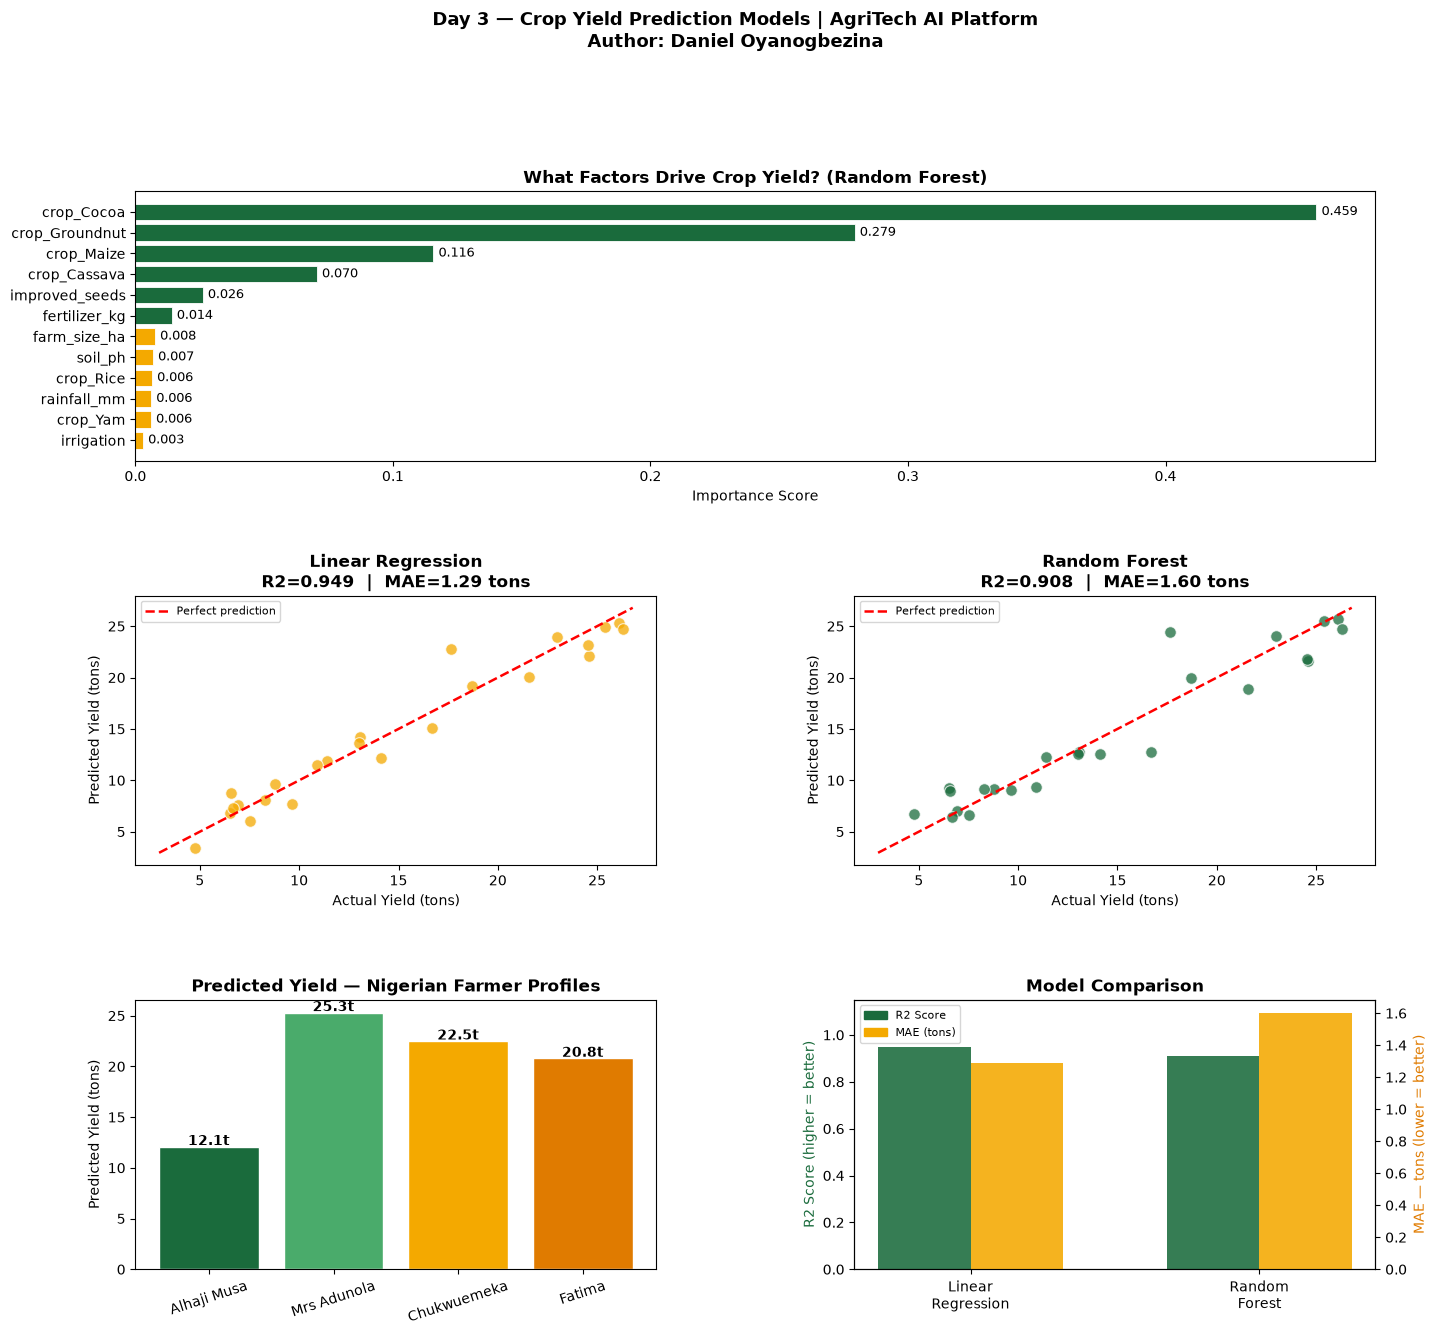

Dashboard saved: docs/day03_ml_dashboard.png
Screenshot this for your LinkedIn post!


In [7]:
# =============================================================
# CELL 7 — Full 6-Chart Dashboard
# All variables are guaranteed to exist if Cells 1-6 ran
# No emoji in titles (avoids font warning on Linux)
# =============================================================

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.38)

GREEN  = '#1a6b3c'
LIME   = '#4aab6b'
AMBER  = '#f4a900'
ORANGE = '#e07b00'

# ── Chart 1: Feature Importance (full width) ──────────────────
ax1 = fig.add_subplot(gs[0, :])

imp_sorted = importance_df.sort_values('Importance', ascending=True)
bar_colors = [GREEN if v >= imp_sorted['Importance'].median()
              else AMBER for v in imp_sorted['Importance']]

bars1 = ax1.barh(imp_sorted['Factor'], imp_sorted['Importance'],
                  color=bar_colors, edgecolor='white', linewidth=0.6)
ax1.set_title('What Factors Drive Crop Yield? (Random Forest)',
              fontweight='bold', fontsize=12)
ax1.set_xlabel('Importance Score')

for bar, val in zip(bars1, imp_sorted['Importance']):
    ax1.text(val + 0.002,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)

# ── Chart 2: Actual vs Predicted — Linear Regression ──────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_test, lr_preds, color=AMBER, alpha=0.75,
            s=70, edgecolors='white', linewidth=0.8)
lo = float(min(y_test.min(), lr_preds.min())) - 0.5
hi = float(max(y_test.max(), lr_preds.max())) + 0.5
ax2.plot([lo, hi], [lo, hi], 'r--', linewidth=1.8, label='Perfect prediction')
ax2.set_xlabel('Actual Yield (tons)')
ax2.set_ylabel('Predicted Yield (tons)')
ax2.set_title(f'Linear Regression\nR2={lr_r2:.3f}  |  MAE={lr_mae:.2f} tons',
              fontweight='bold')
ax2.legend(fontsize=8)

# ── Chart 3: Actual vs Predicted — Random Forest ──────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(y_test, rf_preds, color=GREEN, alpha=0.75,
            s=70, edgecolors='white', linewidth=0.8)
ax3.plot([lo, hi], [lo, hi], 'r--', linewidth=1.8, label='Perfect prediction')
ax3.set_xlabel('Actual Yield (tons)')
ax3.set_ylabel('Predicted Yield (tons)')
ax3.set_title(f'Random Forest\nR2={rf_r2:.3f}  |  MAE={rf_mae:.2f} tons',
              fontweight='bold')
ax3.legend(fontsize=8)

# ── Chart 4: Farmer Scenario Predictions ──────────────────────
ax4 = fig.add_subplot(gs[2, 0])
s_names  = [s['name'].split('—')[0].strip() for s in scenarios]
s_yields = [
    predict_yield(s['rainfall'], s['soil_ph'], s['fertilizer'],
                  s['improved_seeds'], s['irrigation'],
                  s['farm_size'], s['crop'])
    for s in scenarios
]
s_colors = [GREEN, LIME, AMBER, ORANGE]
bars4 = ax4.bar(s_names, s_yields, color=s_colors, edgecolor='white')
ax4.set_title('Predicted Yield — Nigerian Farmer Profiles',
              fontweight='bold')
ax4.set_ylabel('Predicted Yield (tons)')
ax4.tick_params(axis='x', rotation=18)
for bar, val in zip(bars4, s_yields):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.15,
             f'{val}t', ha='center', fontweight='bold', fontsize=10)

# ── Chart 5: Model Comparison ─────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
x      = np.arange(2)
width  = 0.32
labels = ['Linear\nRegression', 'Random\nForest']

bars_r2 = ax5.bar(x - width / 2,
                   [max(0, lr_r2), max(0, rf_r2)],
                   width, label='R2 Score', color=GREEN, alpha=0.88)
ax5b = ax5.twinx()
bars_mae = ax5b.bar(x + width / 2,
                     [lr_mae, rf_mae],
                     width, label='MAE (tons)', color=AMBER, alpha=0.88)

ax5.set_xticks(x)
ax5.set_xticklabels(labels)
ax5.set_ylabel('R2 Score (higher = better)', color=GREEN)
ax5b.set_ylabel('MAE — tons (lower = better)', color=ORANGE)
ax5.set_ylim(0, 1.15)
ax5.set_title('Model Comparison', fontweight='bold')

patches = [plt.Rectangle((0,0),1,1, color=GREEN),
           plt.Rectangle((0,0),1,1, color=AMBER)]
ax5.legend(patches, ['R2 Score', 'MAE (tons)'], loc='upper left', fontsize=8)

# ── Main title ────────────────────────────────────────────────
plt.suptitle(
    'Day 3 — Crop Yield Prediction Models | AgriTech AI Platform\n'
    'Author: Daniel Oyanogbezina',
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('docs/day03_ml_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved: docs/day03_ml_dashboard.png")
print("Screenshot this for your LinkedIn post!")


In [8]:
# =============================================================
# CELL 8 — Save Everything + Day 3 Reflection
# =============================================================
import pickle

# Save the Random Forest pipeline (imputer + model together)
with open('models/yield_predictor_v1.pkl', 'wb') as f:
    pickle.dump(rf_pipeline, f)

# Save the feature column names (needed to reload model later)
with open('models/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

# Save dataset used for training
df.to_csv('datasets/crops/nigeria_farms_day3.csv', index=False)

print("Files saved:")
print("  models/yield_predictor_v1.pkl  <- trained Random Forest pipeline")
print("  models/feature_cols.pkl        <- list of feature names")
print("  datasets/crops/nigeria_farms_day3.csv")

# ── Quick proof the saved model loads and predicts correctly ──
print("\nLoading and testing saved model...")
with open('models/yield_predictor_v1.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

test_row = pd.DataFrame([{f: 0 for f in feature_cols}])
test_row['rainfall_mm']    = 1200
test_row['soil_ph']        = 6.2
test_row['fertilizer_kg']  = 100
test_row['improved_seeds'] = 1
test_row['irrigation']     = 1
test_row['farm_size_ha']   = 4.0
test_row['crop_Cassava']   = 1

test_pred = round(loaded_model.predict(test_row)[0], 1)
print(f"Test prediction (cassava, 1200mm rain, full inputs): {test_pred} tons")
print("Saved model loads and predicts correctly!")

# ── Day 3 Reflection ──────────────────────────────────────────
print("""
=============================================================
  DAY 3 REFLECTION
=============================================================

  What I mastered today:
  [x] What Machine Learning really is (patterns, not magic)
  [x] Why dataset quality matters more than the algorithm
  [x] Feature engineering using agroforestry knowledge
  [x] Train/test split — the golden rule of ML
  [x] sklearn Pipeline — professional NaN handling
  [x] Linear Regression — fast baseline model
  [x] Random Forest — 100 trees, higher accuracy
  [x] MAE and R2 — reading model performance correctly
  [x] Feature importance — what the model actually learned
  [x] Predicted yield for 4 real Nigerian farmer profiles
  [x] Saved model to disk for reuse tomorrow

  Key insight:
  The model's accuracy depends on the QUALITY of the data
  you feed it, not just the algorithm you choose.
  Pure random data = random predictions.
  Data with real agronomic patterns = useful predictions.
  This is why your agroforestry background is irreplaceable.

  Tomorrow — Day 4:
  -> Load today's saved model (no retraining needed)
  -> Connect it to a simple command-line tool
  -> Farmer types their farm conditions -> gets prediction
  -> First step toward the real mobile app

  Day 3 of 365 complete.
=============================================================
""")

Files saved:
  models/yield_predictor_v1.pkl  <- trained Random Forest pipeline
  models/feature_cols.pkl        <- list of feature names
  datasets/crops/nigeria_farms_day3.csv

Loading and testing saved model...
Test prediction (cassava, 1200mm rain, full inputs): 25.7 tons
Saved model loads and predicts correctly!

  DAY 3 REFLECTION

  What I mastered today:
  [x] What Machine Learning really is (patterns, not magic)
  [x] Why dataset quality matters more than the algorithm
  [x] Feature engineering using agroforestry knowledge
  [x] Train/test split — the golden rule of ML
  [x] sklearn Pipeline — professional NaN handling
  [x] Linear Regression — fast baseline model
  [x] Random Forest — 100 trees, higher accuracy
  [x] MAE and R2 — reading model performance correctly
  [x] Feature importance — what the model actually learned
  [x] Predicted yield for 4 real Nigerian farmer profiles
  [x] Saved model to disk for reuse tomorrow

  Key insight:
  The model's accuracy depends on th